In [35]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import statsmodels as sm
import warnings
import numpy as np
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('result.csv')
df.head()

,Unnamed: 0,track_id,DateTime,latitude,longitude,altitude,temp,region,water_dist,building_dist,green_dist,water_area,building_area,green_area,season,hour,water_and_fire_risk,water_and_fire_cluster,evac_difficulty_lvl
0,0,1,2022-03-23 03:47:32,28.526319,77.205764,233.448227,21.0,Region 1,483.748137,17.263341,219.293124,9.614001,1361.365668,9.068051,Весна,3,0,1,2
1,1,1,2022-03-23 03:47:33,28.526304,77.205761,233.366989,16.0,Region 1,484.978274,18.888186,220.963695,9.614001,1361.576094,9.068051,Весна,3,0,1,2
2,2,1,2022-03-23 03:47:34,28.526298,77.205760,233.334747,25.0,Region 1,485.481786,19.533009,221.631384,9.614001,1353.855885,9.068051,Весна,3,0,1,2
3,3,1,2022-03-23 03:47:35,28.526288,77.205757,233.280121,19.0,Region 1,486.250814,20.664223,222.748454,9.614001,1350.015010,9.068051,Весна,3,0,1,2
4,4,1,2022-03-23 03:47:36,28.526277,77.205755,233.228973,21.0,Region 1,487.167542,21.860118,223.973323,9.614001,1350.783267,9.068051,Весна,3,0,1,2


In [7]:
df['DateTime']=pd.to_datetime(df['DateTime'])

In [8]:
temp_series = df.groupby(df['DateTime'].dt.month)['temp'].mean()

In [19]:
from itertools import product
ps = range(1, 5)
d = 1
qs = range(1, 5)
Ps = range(0, 2)
D = 1
Qs = range(0, 2)
s = 12
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

64

In [28]:
def optimizeSARIMA(series, parameters_list, d, D, s):
    results = []
    best_aic = float("inf")

    for param in parameters_list:
        try:
            model = sm.tsa.statespace.sarimax.SARIMAX(
                series,
                order=(param[0], d, param[1]),
                seasonal_order=(param[2], D, param[3], s),
            ).fit(disp=-1)
        except:
            continue
        aic = model.aic
        if aic < best_aic:
            best_model = model
            best_aic = aic
            best_param = param
        results.append([param, model.aic])

    result_table = pd.DataFrame(results)
    print(result_table.shape)
    result_table.columns = ["parameters", "aic"]
    result_table = result_table.sort_values(by="aic", ascending=True).reset_index(
        drop=True
    )
    return result_table




In [29]:
result_table = optimizeSARIMA(temp_series, parameters_list, d, D, s)

Exception ignored in: <function tqdm.__del__ at 0x0000014B677DEB60>
Traceback (most recent call last):
  File "c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


(64, 2)


In [30]:
result_table

,parameters,aic
0,"(1, 1, 0, 0)",6.0
1,"(1, 1, 0, 1)",8.0
2,"(1, 1, 1, 0)",8.0
3,"(1, 2, 0, 0)",8.0
4,"(2, 1, 0, 0)",8.0
...,...,...
59,"(3, 4, 1, 1)",20.0
60,"(4, 3, 1, 1)",20.0
61,"(4, 4, 0, 1)",20.0
62,"(4, 4, 1, 0)",20.0


In [32]:
p, q, P, Q = result_table.parameters[0]

best_model = sm.tsa.statespace.sarimax.SARIMAX(
    temp_series, order=(p, d, q), seasonal_order=(P, D, Q, s)
).fit(disp=-1)

In [33]:
temp_forecast = best_model.forecast(steps=120)

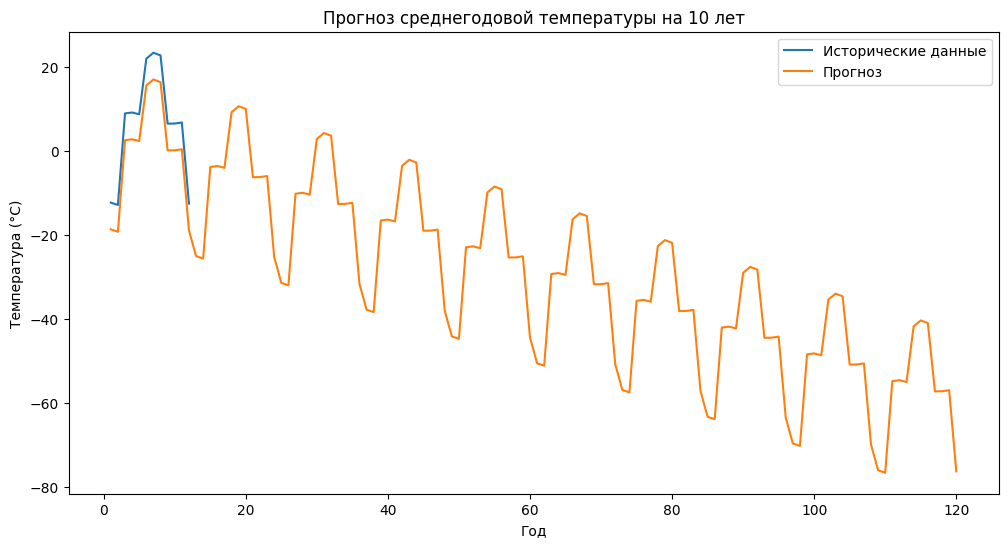

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(temp_series.index, temp_series, label='Исторические данные')
plt.plot(range(1,121), temp_forecast, label='Прогноз')
plt.title('Прогноз среднегодовой температуры на 10 лет')
plt.xlabel('Год')
plt.ylabel('Температура (°C)')
plt.legend()
plt.show()

In [ ]:
future_years = pd.date_range(start=df['DateTime'].max(), periods=10*365, freq='D')
future_data = pd.DataFrame({
    'DateTime': future_years,
    'temp': np.random.normal(loc=temp_forecast.mean(), scale=1, size=len(future_years)),
    'water_dist': df['water_dist'].mean(),
    'building_dist': df['building_dist'].mean(),
    'green_dist': df['green_dist'].mean(),
    'water_area': df['water_area'].mean(),
    'building_area': df['building_area'].mean(),
    'green_area': df['green_area'].mean(),
    'hour': np.random.randint(0, 24, size=len(future_years)),
    'season': [['winter', 'spring', 'summer', 'autumn'][(m-1)//3] for m in future_years.month]
})

# Преобразуем категориальные переменные
future_X = pd.get_dummies(future_data[['temp', 'water_dist', 'building_dist', 'green_dist', 
                                     'water_area', 'building_area', 'green_area', 'season', 'hour']],
                         columns=['season'])

# МОДЕЛЬ ДЛЯ КЛАССИФФИКАЦИИ ОПАСНОСТИ
future_data['predicted_cluster'] = model.predict(future_X)

# 5. Визуализация результатов
plt.figure(figsize=(14, 7))
sns.countplot(x=future_data['DateTime'].dt.year, hue=future_data['predicted_cluster'])
plt.title('Прогноз распределения кластеров опасности по годам')
plt.xlabel('Год')
plt.ylabel('Количество точек')
plt.legend(title='Кластер опасности', labels=['Нет опасности', 'Подтопление', 'Пожароопасность'])
plt.show()